# Properties of Functions: Injective, Surjective, Bijective

This notebook follows the same style as the previous lesson and explains:

- injective functions (injections)
- surjective functions (surjections)
- bijective functions (bijections)
- inverse functions
- why these ideas matter
- Python examples
- visual mapping diagrams


## 1. Reminder: what is a function?

A function

$$
f : X \to Y
$$

maps each input from the domain $X$ to **exactly one** output in the codomain $Y$.

Today we classify functions into three important types:

1. **Injective** — different inputs give different outputs  
2. **Surjective** — every codomain element gets hit  
3. **Bijective** — both injective and surjective


## 2. Why these properties matter

Functions with different properties are useful in different situations.

Example: encryption / ciphers.

A good reversible cipher should be at least **injective**:

- different messages should not encrypt to the same ciphertext

Otherwise decoding becomes ambiguous.


## 3. Injective functions

A function

$$
f : X \to Y
$$

is **injective** if no two different inputs map to the same output.

Formally:

$$
f(x_1) = f(x_2) \Rightarrow x_1 = x_2
$$

for all $x_1,x_2 \in X$.

Equivalent meaning:

> Different inputs always give different outputs.


## 4. Visual intuition for injective functions

In an arrow diagram:

- each domain element has one arrow out
- no two arrows land on the same codomain element


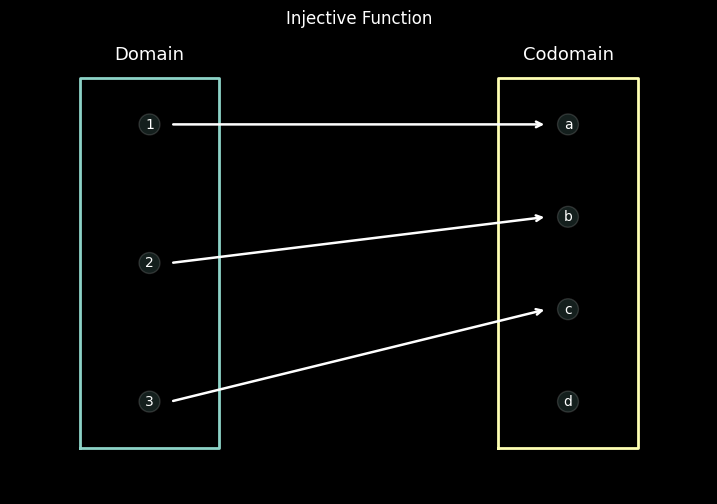

In [1]:
import matplotlib.pyplot as plt

def draw_mapping(domain, codomain, arrows, title="Mapping"):
    fig, ax = plt.subplots(figsize=(9, 6))
    ax.set_xlim(0, 10)
    ax.set_ylim(0, 10)
    ax.axis('off')

    ax.plot([1,3,3,1,1],[1,1,9,9,1], linewidth=2)
    ax.plot([7,9,9,7,7],[1,1,9,9,1], linewidth=2)

    ax.text(2, 9.4, "Domain", ha='center', fontsize=13)
    ax.text(8, 9.4, "Codomain", ha='center', fontsize=13)

    d_y = {}
    c_y = {}

    for i,v in enumerate(domain):
        ypos = 8 - i*(6/max(1,len(domain)-1)) if len(domain)>1 else 5
        d_y[v] = ypos
        ax.text(2, ypos, str(v), ha='center', va='center',
                bbox=dict(boxstyle="circle,pad=0.25", alpha=0.15))

    for i,v in enumerate(codomain):
        ypos = 8 - i*(6/max(1,len(codomain)-1)) if len(codomain)>1 else 5
        c_y[v] = ypos
        ax.text(8, ypos, str(v), ha='center', va='center',
                bbox=dict(boxstyle="circle,pad=0.25", alpha=0.15))

    for x,y in arrows:
        ax.annotate("", xy=(7.7,c_y[y]), xytext=(2.3,d_y[x]),
                    arrowprops=dict(arrowstyle="->", lw=1.8))

    ax.set_title(title)
    plt.show()

draw_mapping(
    domain=[1,2,3],
    codomain=['a','b','c','d'],
    arrows=[(1,'a'),(2,'b'),(3,'c')],
    title="Injective Function"
)


## 5. Example: $f(x)=x+1$ on integers

Let

$$
f : \mathbb{Z} \to \mathbb{Z}, \qquad f(x)=x+1
$$

This function is injective because:

$$
x_1+1 = x_2+1 \Rightarrow x_1=x_2
$$


In [2]:
def f(x):
    return x + 1

vals = [-2,-1,0,1,2]
for x in vals:
    print(f"f({x}) = {f(x)}")


f(-2) = -1
f(-1) = 0
f(0) = 1
f(1) = 2
f(2) = 3


## 6. Another injective example: $g(x)=3x$

Let

$$
g : \mathbb{Z} \to \mathbb{Z}, \qquad g(x)=3x
$$

This is injective because:

$$
3x_1 = 3x_2 \Rightarrow x_1=x_2
$$


In [3]:
def g(x):
    return 3*x

for x in [-2,-1,0,1,2]:
    print(f"g({x}) = {g(x)}")


g(-2) = -6
g(-1) = -3
g(0) = 0
g(1) = 3
g(2) = 6


## 7. Non-injective example: $h(x)=x^2$

Let

$$
h : \mathbb{Z} \to \mathbb{Z}, \qquad h(x)=x^2
$$

This is **not injective** because:

$$
h(2)=4, \qquad h(-2)=4
$$

Different inputs gave the same output.


In [4]:
def h(x):
    return x*x

for x in [-3,-2,-1,0,1,2,3]:
    print(f"h({x}) = {h(x)}")


h(-3) = 9
h(-2) = 4
h(-1) = 1
h(0) = 0
h(1) = 1
h(2) = 4
h(3) = 9


## 8. Surjective functions

A function

$$
f : X \to Y
$$

is **surjective** (onto) if every element of the codomain is the image of some input.

Formally:

$$
\forall y \in Y, \exists x \in X \text{ such that } f(x)=y
$$

Meaning:

> Every target value gets hit by at least one arrow.


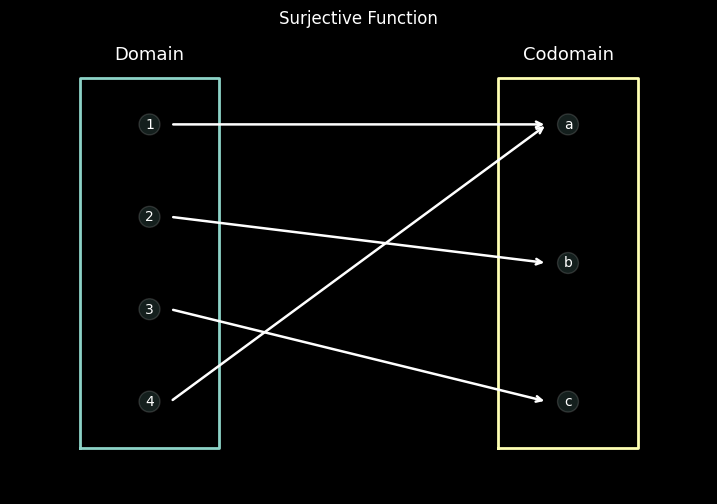

In [5]:
draw_mapping(
    domain=[1,2,3,4],
    codomain=['a','b','c'],
    arrows=[(1,'a'),(2,'b'),(3,'c'),(4,'a')],
    title="Surjective Function"
)


## 9. Example: $f(x)=x+1$ on integers is surjective

Let

$$
f : \mathbb{Z} \to \mathbb{Z}, \qquad f(x)=x+1
$$

Take any integer $y$.

Choose:

$$
x = y-1
$$

Then:

$$
f(x)=f(y-1)=y
$$

So every integer is hit.


In [6]:
def f(x):
    return x+1

targets = [-3,0,7]
for y in targets:
    x = y - 1
    print(f"Target y={y}, choose x={x}, then f(x)={f(x)}")


Target y=-3, choose x=-4, then f(x)=-3
Target y=0, choose x=-1, then f(x)=0
Target y=7, choose x=6, then f(x)=7


## 10. Non-surjective examples

### Example 1: $g(x)=3x$

As a map

$$
g : \mathbb{Z} \to \mathbb{Z}
$$

it is **not surjective**, because numbers like 1,2,4,5 are not multiples of 3.

### Example 2: $h(x)=x^2$

As a map

$$
h : \mathbb{Z} \to \mathbb{Z}
$$

it is not surjective because negative integers are never squares.


In [7]:
def g(x): return 3*x
def h(x): return x*x

outputs_g = {g(x) for x in range(-5,6)}
outputs_h = {h(x) for x in range(-5,6)}

print("Some outputs of g(x)=3x:", sorted(outputs_g))
print("Some outputs of h(x)=x^2:", sorted(outputs_h))


Some outputs of g(x)=3x: [-15, -12, -9, -6, -3, 0, 3, 6, 9, 12, 15]
Some outputs of h(x)=x^2: [0, 1, 4, 9, 16, 25]


## 11. Bijective functions

A function is **bijective** if it is both:

- injective
- surjective

That means:

> Every codomain element is hit by exactly one input.


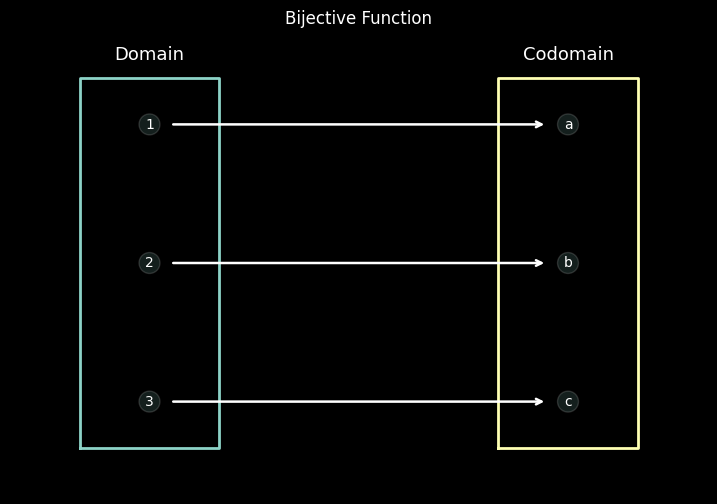

In [8]:
draw_mapping(
    domain=[1,2,3],
    codomain=['a','b','c'],
    arrows=[(1,'a'),(2,'b'),(3,'c')],
    title="Bijective Function"
)


## 12. Example: $f(x)=x+1$ on integers is bijective

We already showed:

- injective
- surjective

Therefore:

$$
f(x)=x+1
$$

as a map

$$
\mathbb{Z} \to \mathbb{Z}
$$

is bijective.


## 13. Inverse functions

If a function is bijective, then it has an inverse:

$$
f^{-1} : Y \to X
$$

which reverses the mapping.

If:

$$
f(x)=x+1
$$

then:

$$
f^{-1}(y)=y-1
$$


In [9]:
def f(x):
    return x+1

def f_inv(y):
    return y-1

for x in [-2,0,5]:
    y = f(x)
    back = f_inv(y)
    print(f"x={x} -> y={y} -> back={back}")


x=-2 -> y=-1 -> back=-2
x=0 -> y=1 -> back=0
x=5 -> y=6 -> back=5


## 14. Cube and cube root

Let

$$
f : \mathbb{R} \to \mathbb{R}, \qquad f(x)=x^3
$$

This is bijective over the real numbers.

Its inverse is:

$$
f^{-1}(y)=\sqrt[3]{y}
$$


In [10]:
def cube(x):
    return x**3

def cube_root(y):
    # keeps sign correctly
    return y ** (1/3) if y >= 0 else -((-y) ** (1/3))

for x in [-3,-1,0,2]:
    y = cube(x)
    back = cube_root(y)
    print(f"x={x:>2} -> cube={y:>3} -> inverse≈{back:.6f}")


x=-3 -> cube=-27 -> inverse≈-3.000000
x=-1 -> cube= -1 -> inverse≈-1.000000
x= 0 -> cube=  0 -> inverse≈0.000000
x= 2 -> cube=  8 -> inverse≈2.000000


## 15. Finite-function checker in Python

For finite sets, we can test injective / surjective / bijective using dictionaries.


In [11]:
def classify_mapping(mapping, codomain):
    outputs = list(mapping.values())
    output_set = set(outputs)

    injective = len(outputs) == len(output_set)
    surjective = output_set == set(codomain)
    bijective = injective and surjective

    return injective, surjective, bijective

mapping1 = {1:'a', 2:'b', 3:'c'}
mapping2 = {1:'a', 2:'a', 3:'b'}
mapping3 = {1:'a', 2:'b'}

codomain = {'a','b','c'}

for i,m in enumerate([mapping1,mapping2,mapping3], start=1):
    inj,sur,bij = classify_mapping(m, codomain)
    print(f"mapping{i}: {m}")
    print(" injective :", inj)
    print(" surjective:", sur)
    print(" bijective :", bij)
    print()


mapping1: {1: 'a', 2: 'b', 3: 'c'}
 injective : True
 surjective: True
 bijective : True

mapping2: {1: 'a', 2: 'a', 3: 'b'}
 injective : False
 surjective: False
 bijective : False

mapping3: {1: 'a', 2: 'b'}
 injective : True
 surjective: False
 bijective : False



## 16. Why ciphers need injective functions

Suppose:

- message A encrypts to `XZ`
- message B also encrypts to `XZ`

Then when you see `XZ`, you cannot know the original message.

So encryption needs at least injectivity.

For reversible perfect decoding, bijectivity is ideal.


In [12]:
messages = {
    "HELLO": "XZ",
    "WORLD": "XZ"
}

print("Bad cipher example:")
for msg, enc in messages.items():
    print(msg, "->", enc)

print("\nProblem: same ciphertext for different messages.")


Bad cipher example:
HELLO -> XZ
WORLD -> XZ

Problem: same ciphertext for different messages.


## 17. Summary table

| Property | Meaning |
|---|---|
| Injective | Different inputs give different outputs |
| Surjective | Every codomain value is hit |
| Bijective | Both injective and surjective |
| Inverse exists | For bijections |


## 18. Exercises

1. Is $f(x)=2x$ from integers to integers injective? Surjective?

2. Is $f(x)=x^2$ from real numbers to real numbers injective? Surjective?

3. Is $f(x)=x^3$ from real numbers to real numbers bijective?

4. Find the inverse of $f(x)=x-7$.


In [13]:
# Sample thoughts / quick answers

print("1. f(x)=2x on Z:")
print("- injective: yes")
print("- surjective onto Z: no (odd numbers missing)")
print()

print("2. f(x)=x^2 on R:")
print("- injective: no (x and -x)")
print("- surjective onto R: no (negatives missing)")
print()

print("3. f(x)=x^3 on R:")
print("- bijective: yes")
print()

print("4. Inverse of x-7 is y+7")


1. f(x)=2x on Z:
- injective: yes
- surjective onto Z: no (odd numbers missing)

2. f(x)=x^2 on R:
- injective: no (x and -x)
- surjective onto R: no (negatives missing)

3. f(x)=x^3 on R:
- bijective: yes

4. Inverse of x-7 is y+7


## 19. Final conclusion

You learned three major classes of functions:

- **Injective**: no collisions
- **Surjective**: nothing missed
- **Bijective**: perfect one-to-one correspondence

Bijective functions are especially powerful because they can be reversed using an inverse function.
